In [1]:
import pertpy as pt


/software/cellgen/team298/ls34/sccoda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# from pertpy.tl import EdgeR

In [3]:
import warnings

import decoupler as dc
import scanpy as sc

warnings.filterwarnings("ignore")

## Dataset

In [31]:
#PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
PATH = '/nfs/team361/ls34/inflow/adata_hs_tdc.h5ad'

adata_5k=sc.read_h5ad(PATH)
#adata_5k=adata_5k[adata_5k.obs["tech"]=="xenium"].copy()
import gc
gc.collect()


def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST



adata_5k.obs["lvl5_annotation_new"]=adata_5k.obs["fine_annotation"]

adata=adata_5k

adata.obs["sample_id"].value_counts()

sample_id
output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553    5045
output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127        1962
output-XETG00272__0021042__AX29-SKI-0-FO-1-S4__20240815__114049         1412
output-XETG00155__0032945__AX34-SKI-0-FO-2-S3-A2__20241217__145711      1281
output-XETG00272__0027175__Region_7__20240628__124459                   1269
output-XETG00272__0041416__BK23-SKI-27-FO-1-S6-C2__20241107__113553     1003
output-XETG00155__0043607__BK30-SKI-27-FO-1-2-S3__20241010__133127       863
output-XETG00272__0027131__Region_7__20240628__124459                    757
output-XETG00272__0021042__AX30-SKI-0-FO-1-S3__20240815__114049          575
output-XETG00155__0032957__AX38-SKI-0-FO-1-S3-B1__20241217__145711       437
Name: count, dtype: int64

In [32]:
#adata = adata[adata.obs["Site_status_v"] == "Lesional", :].copy()
#adata.obs.Site_status_binary.value_counts()
adata.obs["Patient"]=adata.obs["sample_id"]
#adata.obs["Patient"]=adata.obs["sample_id"]
adata.obs["Sample"]=adata.obs["sample_id"]
# Step 1: Calculate total counts per patient
patient_counts = adata.obs.groupby("Patient").size()

# Step 2: Identify patients with more than 5000 counts
#patients_to_exclude = patient_counts[patient_counts < 10000].index

# Step a: Exclude those patients from adata
#adata = adata[~adata.obs["Patient"].isin(patients_to_exclude)].copy()
#adata=adata[adata.obs["Timepoint"]!="UNKNOWN_FFPE"]
#a#data.obs["Patient"].value_counts()
#adata=adata[~adata.obs["Patient"].isin(['BK50', 'BK49', 'BK43', 'BK46', 'BK51'])]
adata.obs["Group"]=adata.obs["Site_status_binary"]
adata.obs["disease_overall"]=adata.obs["disease"]

adata.obs["Major celltype"] = adata.obs["fine_annotation"]
adata.obs["Cluster"]=adata.obs["fine_annotation"] 

In [33]:
for x in adata.obs.columns:
    if x not in ["Cluster", "Major celltype", "disease_overall", "Site_status", "Group", "Sample", "Patient"]:
        del(adata.obs[x])


In [34]:
# {x:"" for x in adata[adata.obs["disease_overall"]=="Psoriasis"].obs["Sample"].unique()}

When conducting differential gene expression analysis, it is important to understand the dataset well.
We will therefore explore the various co-variates first.

In [35]:
# RENAME = {'output-XETG00155__0056910__CE6-SKI-28-FO-1-S22-B2__20250321__130447': 'CE6',
#  'output-XETG00155__0056910__CE5-SKI-28-FO-1-S22-A1__20250321__130447': 'CE5',
#  'output-XETG00155__0056918__CE3-SKI-28-FO-1-S22-B1__20250321__130447': 'CE3',
#  'output-XETG00155__0056918__CE4-SKI-27-FO-1-S22-B2__20250321__130447': 'CE4',
#  'output-XETG00155__0056910__CE6-SKI-28-FO-4-S22-A1__20250321__130447': 'CE6',
#  'output-XETG00155__0056910__CE5-SKI-27-FO-2-S22-C1__20250321__130447': 'CE5',
#  'output-XETG00155__0056918__CE3-SKI-24-FO-1-S22-A1__20250321__130447': 'CE3',
#  'output-XETG00155__0056918__CE4-SKI-21-FO-1-S22-C2__20250321__130447': 'CE4',
#  'output-XETG00155__0056910__CE5-SKI-27-FO-1-S22-B1__20250321__130447': 'CE5',
#  'output-XETG00155__0056918__CE3-SKI-28-FO-2-S22-C1__20250321__130447': 'CE3',
#  'output-XETG00155__0056918__CE4-SKI-27-FO-4-S22-A2__20250321__130447': 'CE4',
#  'output-XETG00155__0056910__CE6-SKI-20-FO-1-S22-C2__20250321__130447': 'CE6'}
# adata.obs["Patient"] = adata.obs["Sample"].map(RENAME).fillna(adata.obs["Patient"])

## Pseudobulks

In [36]:
adata.layers["counts"] = adata.X.copy()


In [37]:
# adata.X=adata.layers["counts"].copy()

In [38]:
# adata.obs["Drug"]=adata.obs["Group"]
# adata.obs["Drug"]=adata.obs["Drug"].astype(str)
# #adata.obs["Group"]=adata.obs["Group"].astype('category')
# adata.obs["Group2"]=adata.obs["Group"].astype(str)

# adata

In [39]:
# adata_i=adata[adata.obs["Site_status"]=="Lesional"]

In [40]:
adata_i=adata.copy()
# adata_i[(adata_i.obs["Cluster"].str.startswith("MigDC (cDC2"))
#               # (adata_i.obs["Cluster"].str.startswith("F1"))
#                ].copy()

In [41]:
# adata_i=adata_i.copy()

In [42]:
ps = pt.tl.PseudobulkSpace()
pdata = ps.compute(
    adata_i, 
    target_col='disease_overall',
    #target_col="disease_overall",
   groups_col="Patient", 
    layer_key="counts", mode="sum", min_cells=20, min_counts=1000
)
pdata.obs

,disease_overall,Patient,Sample,Group,psbulk_n_cells,psbulk_counts
HS_output-XETG00155__0032945__AX34-SKI-0-FO-2-S3-A2__20241217__145711,HS,output-XETG00155__0032945__AX34-SKI-0-FO-2-S3-...,output-XETG00155__0032945__AX34-SKI-0-FO-2-S3-...,Lesional,1281.0,64259.0
HS_output-XETG00155__0032957__AX38-SKI-0-FO-1-S3-B1__20241217__145711,HS,output-XETG00155__0032957__AX38-SKI-0-FO-1-S3-...,output-XETG00155__0032957__AX38-SKI-0-FO-1-S3-...,Lesional,437.0,16396.0
AD_output-XETG00155__0043607__BK30-SKI-27-FO-1-2-S3__20241010__133127,AD,output-XETG00155__0043607__BK30-SKI-27-FO-1-2-...,output-XETG00155__0043607__BK30-SKI-27-FO-1-2-...,Lesional,863.0,43144.0
AD_output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127,AD,output-XETG00155__0043607__BK39-SKI-27-FO-1-S3...,output-XETG00155__0043607__BK39-SKI-27-FO-1-S3...,Lesional,1962.0,115216.0
HS_output-XETG00272__0021042__AX29-SKI-0-FO-1-S4__20240815__114049,HS,output-XETG00272__0021042__AX29-SKI-0-FO-1-S4_...,output-XETG00272__0021042__AX29-SKI-0-FO-1-S4_...,Lesional,1412.0,70282.0
HS_output-XETG00272__0021042__AX30-SKI-0-FO-1-S3__20240815__114049,HS,output-XETG00272__0021042__AX30-SKI-0-FO-1-S3_...,output-XETG00272__0021042__AX30-SKI-0-FO-1-S3_...,Lesional,575.0,15126.0
AD_output-XETG00272__0027131__Region_7__20240628__124459,AD,output-XETG00272__0027131__Region_7__20240628_...,output-XETG00272__0027131__Region_7__20240628_...,Lesional,757.0,41806.0
AD_output-XETG00272__0027175__Region_7__20240628__124459,AD,output-XETG00272__0027175__Region_7__20240628_...,output-XETG00272__0027175__Region_7__20240628_...,Lesional,1269.0,74626.0
AD_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553,AD,output-XETG00272__0041416__BK22-SKI-27-FO-1-S1...,output-XETG00272__0041416__BK22-SKI-27-FO-1-S1...,Lesional,5045.0,656874.0
AD_output-XETG00272__0041416__BK23-SKI-27-FO-1-S6-C2__20241107__113553,AD,output-XETG00272__0041416__BK23-SKI-27-FO-1-S6...,output-XETG00272__0041416__BK23-SKI-27-FO-1-S6...,Lesional,1003.0,45873.0


In [43]:
pdata.layers["counts"] = pdata.X.copy()
#pdata.X=pdata.layers["counts"].copy()

sc.pp.normalize_total(pdata, target_sum=1e4)
sc.pp.log1p(pdata)
sc.pp.scale(pdata, max_value=10)
sc.tl.pca(pdata)

# Return raw counts to X
dc.swap_layer(pdata, "counts", X_layer_key=None, inplace=True)

In [44]:
# sc.pl.pca(pdata, color=["disease_overall"], ncols=1, size=300) # "Efficacy", 
# sc.pl.pca(pdata, color=["Cluster"], ncols=1, size=300, legend_loc="on data") # "Efficacy", 
# sc.pl.pca(pdata, color=["Cluster"], ncols=1, size=300, #legend_loc="on data"
#          ) # "Efficacy", 


In [45]:
# sc.pl.pca_variance_ratio(pdata)


In [46]:
# try:
#     dc.get_metadata_associations(
#         pdata,
#         obs_keys=[ "disease_overall", "Patient", "psbulk_n_cells", "psbulk_counts"], # "Treatment", "Patient",
#         obsm_key="X_pca",
#         uns_key="pca_anova",
#         inplace=True,
#     )
#     pdata
# except:
#     1

In [47]:
# try:
#     dc.plot_associations(
#         pdata,
#         uns_key="pca_anova",
#         obsm_key="X_pca",
#         stat_col="p_adj",
#         obs_annotation_cols=["disease_overall",  #"Treatment", "Efficacy", 
#                              "Major celltype"],
#         titles=["Principle component scores", "Adjusted p-values from ANOVA"],
#     )
# except:
#     1

In [48]:
edgr = pt.tl.PyDESeq2(adata=pdata, design="~disease_overall")


In [49]:
edgr.fit()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.25 seconds.

Fitting LFCs...
... done in 0.17 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.



In [50]:
pdata.obs.disease_overall

HS_output-XETG00155__0032945__AX34-SKI-0-FO-2-S3-A2__20241217__145711      HS
HS_output-XETG00155__0032957__AX38-SKI-0-FO-1-S3-B1__20241217__145711      HS
AD_output-XETG00155__0043607__BK30-SKI-27-FO-1-2-S3__20241010__133127      AD
AD_output-XETG00155__0043607__BK39-SKI-27-FO-1-S3__20241010__133127        AD
HS_output-XETG00272__0021042__AX29-SKI-0-FO-1-S4__20240815__114049         HS
HS_output-XETG00272__0021042__AX30-SKI-0-FO-1-S3__20240815__114049         HS
AD_output-XETG00272__0027131__Region_7__20240628__124459                   AD
AD_output-XETG00272__0027175__Region_7__20240628__124459                   AD
AD_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553    AD
AD_output-XETG00272__0041416__BK23-SKI-27-FO-1-S6-C2__20241107__113553     AD
Name: disease_overall, dtype: category
Categories (2, object): ['AD', 'HS']

In [53]:
res_df = edgr.test_contrasts(edgr.contrast(column="disease_overall", baseline="HS", group_to_compare="AD"))

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
ABAT     19.318880       -0.150336  0.418138 -0.359536  0.719194  0.863917
ABCA4     1.882340        0.368036  1.938421  0.189864  0.849416  0.934832
ABCB4     3.543308       -0.036413  0.759006 -0.047975  0.961736  0.983902
ABCC4    17.633920        0.223338  0.486267  0.459292  0.646025  0.814769
ABCC8     0.445553       -1.411301  2.571643 -0.548794  0.583147       NaN
...            ...             ...       ...       ...       ...       ...
ZNF177    1.061686       -0.272201  1.422274 -0.191384  0.848224       NaN
ZNF469   36.922310       -1.472911  0.502297 -2.932347  0.003364  0.023172
ZNF512   95.253863        0.080675  0.295663  0.272862  0.784959  0.895927
ZNF683  441.526445       -0.869888  0.561626 -1.548874  0.121412  0.310626
ZSWIM6    5.871845        0.052404  0.587770  0.089157  0.928957  0.965564

[1193 rows x 6 columns]


... done in 9.60 seconds.



In [ ]:
# res_df.head(10)

The set of differentially expressed genes can now be used for downstream tasks or as a first step, plotted in a volcano plot.

NaNs encountered, dropping rows with NaNs


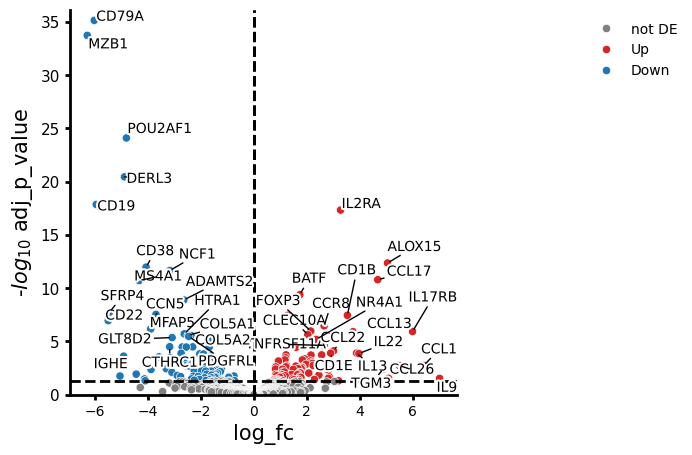

In [59]:
edgr.plot_volcano(res_df, 
                  log2fc_thresh=0,
                     to_label=20
                  ,
                     #    log2fc_thresh=0.
                 )

In [61]:
res_df

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,CD79A,128.279908,-6.037867,0.462987,-13.041117,7.140283e-39,7.033179e-36,None
1,MZB1,274.600819,-6.302519,0.494815,-12.737126,3.676922e-37,1.810884e-34,None
2,POU2AF1,78.493445,-4.823604,0.445198,-10.834745,2.356205e-27,7.736208e-25,None
3,DERL3,113.996828,-4.895256,0.489164,-10.007385,1.414412e-23,3.482990e-21,None
4,CD19,43.518280,-5.963088,0.635990,-9.376072,6.847649e-21,1.348987e-18,None
...,...,...,...,...,...,...,...,...
1188,SP9,2.211592,0.006105,1.037956,0.005881,9.953073e-01,9.991462e-01,None
1189,NFATC1,70.523017,-0.001815,0.371692,-0.004884,9.961031e-01,9.991462e-01,None
1190,MAP3K5,26.571684,-0.001188,0.410178,-0.002897,9.976885e-01,9.997184e-01,None
1191,CSNK1E,78.788766,0.000365,0.263178,0.001385,9.988948e-01,9.997790e-01,None


NaNs encountered, dropping rows with NaNs


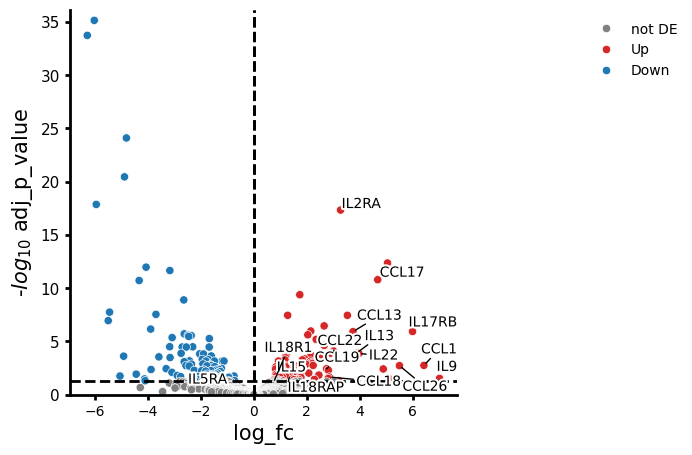

In [66]:
# Build list of genes to label: starts with CCL, CXCL, or IL AND p_value < 0.05
genes_to_label = [
    g
    for g, p in zip(res_df["variable"], res_df["p_value"])
    if g.startswith(("CCL", "CXCL", "IL")) and p < 0.05
]

# Plot volcano
edgr.plot_volcano(
    res_df,
    log2fc_thresh=0,
    to_label=genes_to_label
)

NaNs encountered, dropping rows with NaNs


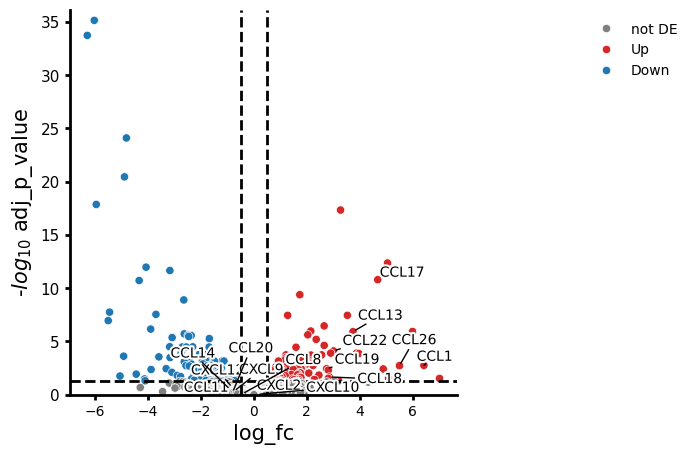

In [63]:
# Filter gene names that start with CCL or CXCL

# Plot volcano
edgr.plot_volcano(
    res_df,
    log2fc_thresh=0.5,      # keep as you had it
    to_label=genes_to_label
)

NaNs encountered, dropping rows with NaNs


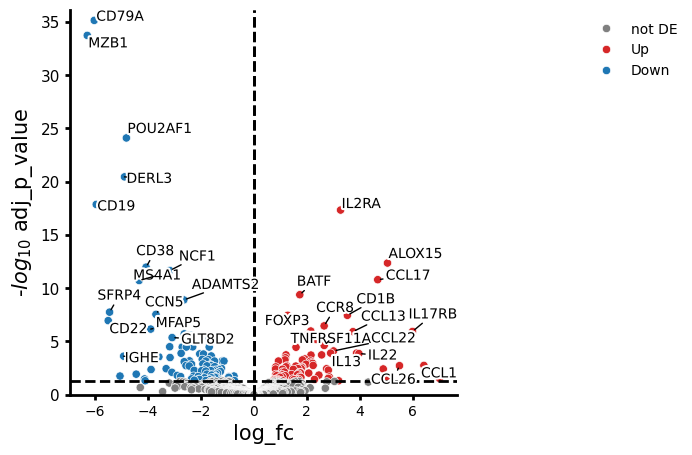

In [55]:
edgr.plot_volcano(res_df, 
                  log2fc_thresh=0,
                     to_label=15
                  ,
                     #    log2fc_thresh=0.
                 )

NaNs encountered, dropping rows with NaNs


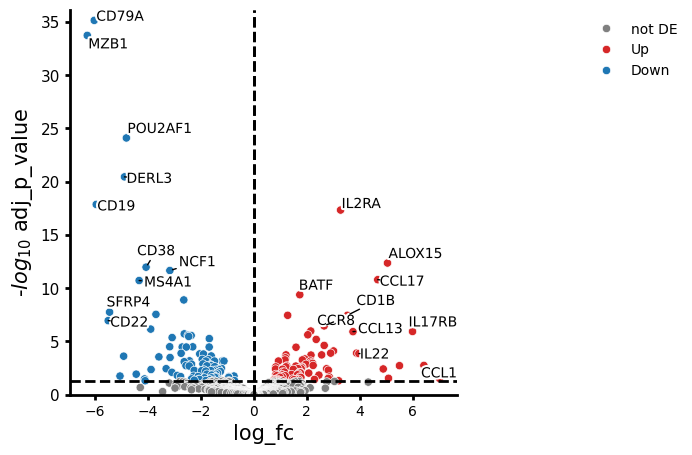

In [56]:
fig = edgr.plot_volcano(
    res_df,
    log2fc_thresh=0,
    to_label=10,
    return_fig=True
)

#fig.savefig("fig3/supp3g_migdc_Dec.pdf", dpi=300, bbox_inches="tight")

NaNs encountered, dropping rows with NaNs


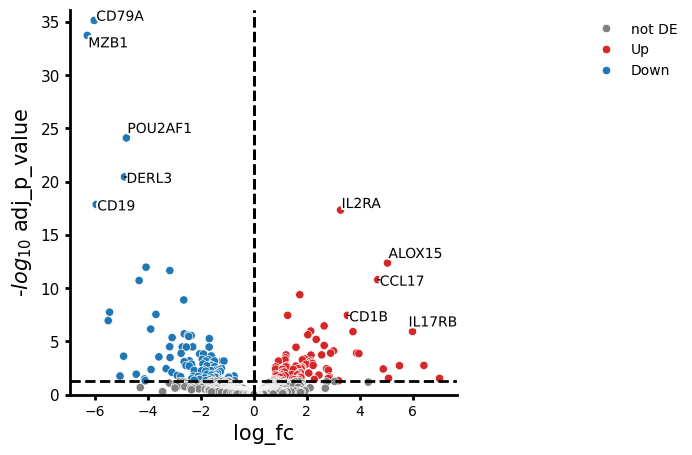

In [57]:
fig = edgr.plot_volcano(
    res_df,
    log2fc_thresh=0,
    to_label=5,
    return_fig=True
)

#fig.savefig("fig3/supp3g_migdc_Dec_cleaner.pdf", dpi=300, bbox_inches="tight")

NaNs encountered, dropping rows with NaNs


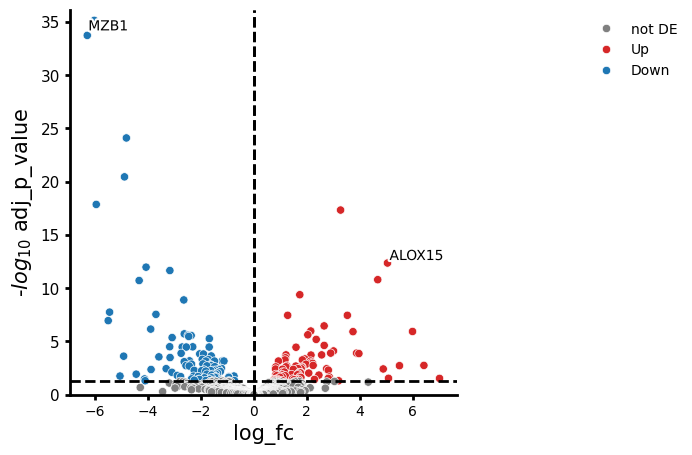

In [58]:
fig = edgr.plot_volcano(
    res_df,
    log2fc_thresh=0,
    to_label=1,
    return_fig=True
)

#fig.savefig("fig3/supp3g_migdc_Dec_cleanest.pdf", dpi=300, bbox_inches="tight")

In [ ]:
edgr.plot_fold_change(res_df, n_top_vars=30)
